In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import torch
from loguru import logger
from omegaconf import OmegaConf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightning as l
from lightning.pytorch.callbacks import ModelCheckpoint

from sdofmv2.core import MAE, MAE_old
from sdofmv2.tasks.f107 import EmbSolarProxyDataModule, MultiLayerPerceptron

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
# Data Organization for Visualization
path = "/home/jinsu/project/sdofmv2/assets/ds_results/f107/"
df_sdofmv1 = pd.read_csv(path + "test_results_sdofmv1-base.csv")
df_sdofmv2_all = pd.read_csv(path + "test_results_ALL.csv")
df_data = pd.read_csv("/home/jinsu/project/sdofmv2/assets/cache/f10.7.csv")
max_val = df_data[" f107"].max()

y_v1 = df_sdofmv1["label"].to_numpy() * max_val
y_v2 = df_sdofmv2_all["label"].to_numpy() * max_val
timestamps_v1 = pd.to_datetime(df_sdofmv1["timestamp"], unit="ns").to_numpy()
timestamps_v2 = pd.to_datetime(df_sdofmv2_all["timestamp"], unit="ns").to_numpy()
preds_sdofmv1 = df_sdofmv1["prediction"].to_numpy() * max_val
preds_sdofmv2_all = df_sdofmv2_all["prediction"].to_numpy() * max_val

In [6]:
r2_sdofmv1 = r2_score(y_v1, preds_sdofmv1)
r2_sdofmv2_all = r2_score(y_v2, preds_sdofmv2_all)

mae_sdofmv1 = mean_absolute_error(y_v1, preds_sdofmv1)
mae_sdofmv2_all = mean_absolute_error(y_v2, preds_sdofmv2_all)

mse_sdofmv1 = mean_squared_error(y_v1, preds_sdofmv1)
mse_sdofmv2_all = mean_squared_error(y_v2, preds_sdofmv2_all)

print(f"SDOFMV1, MAE: {mae_sdofmv1:.2f}, MSE: {mse_sdofmv1:.2f}, R^{2}: {r2_sdofmv1:.4f}")
print(f"SDOFMV2_ALL, MAE: {mae_sdofmv2_all:.2f}, MSE: {mse_sdofmv2_all:.2f}, R^{2}: {r2_sdofmv2_all:.4f}")

SDOFMV1, MAE: 6.15, MSE: 87.00, R^2: 0.9175
SDOFMV2_ALL, MAE: 6.46, MSE: 83.14, R^2: 0.9215


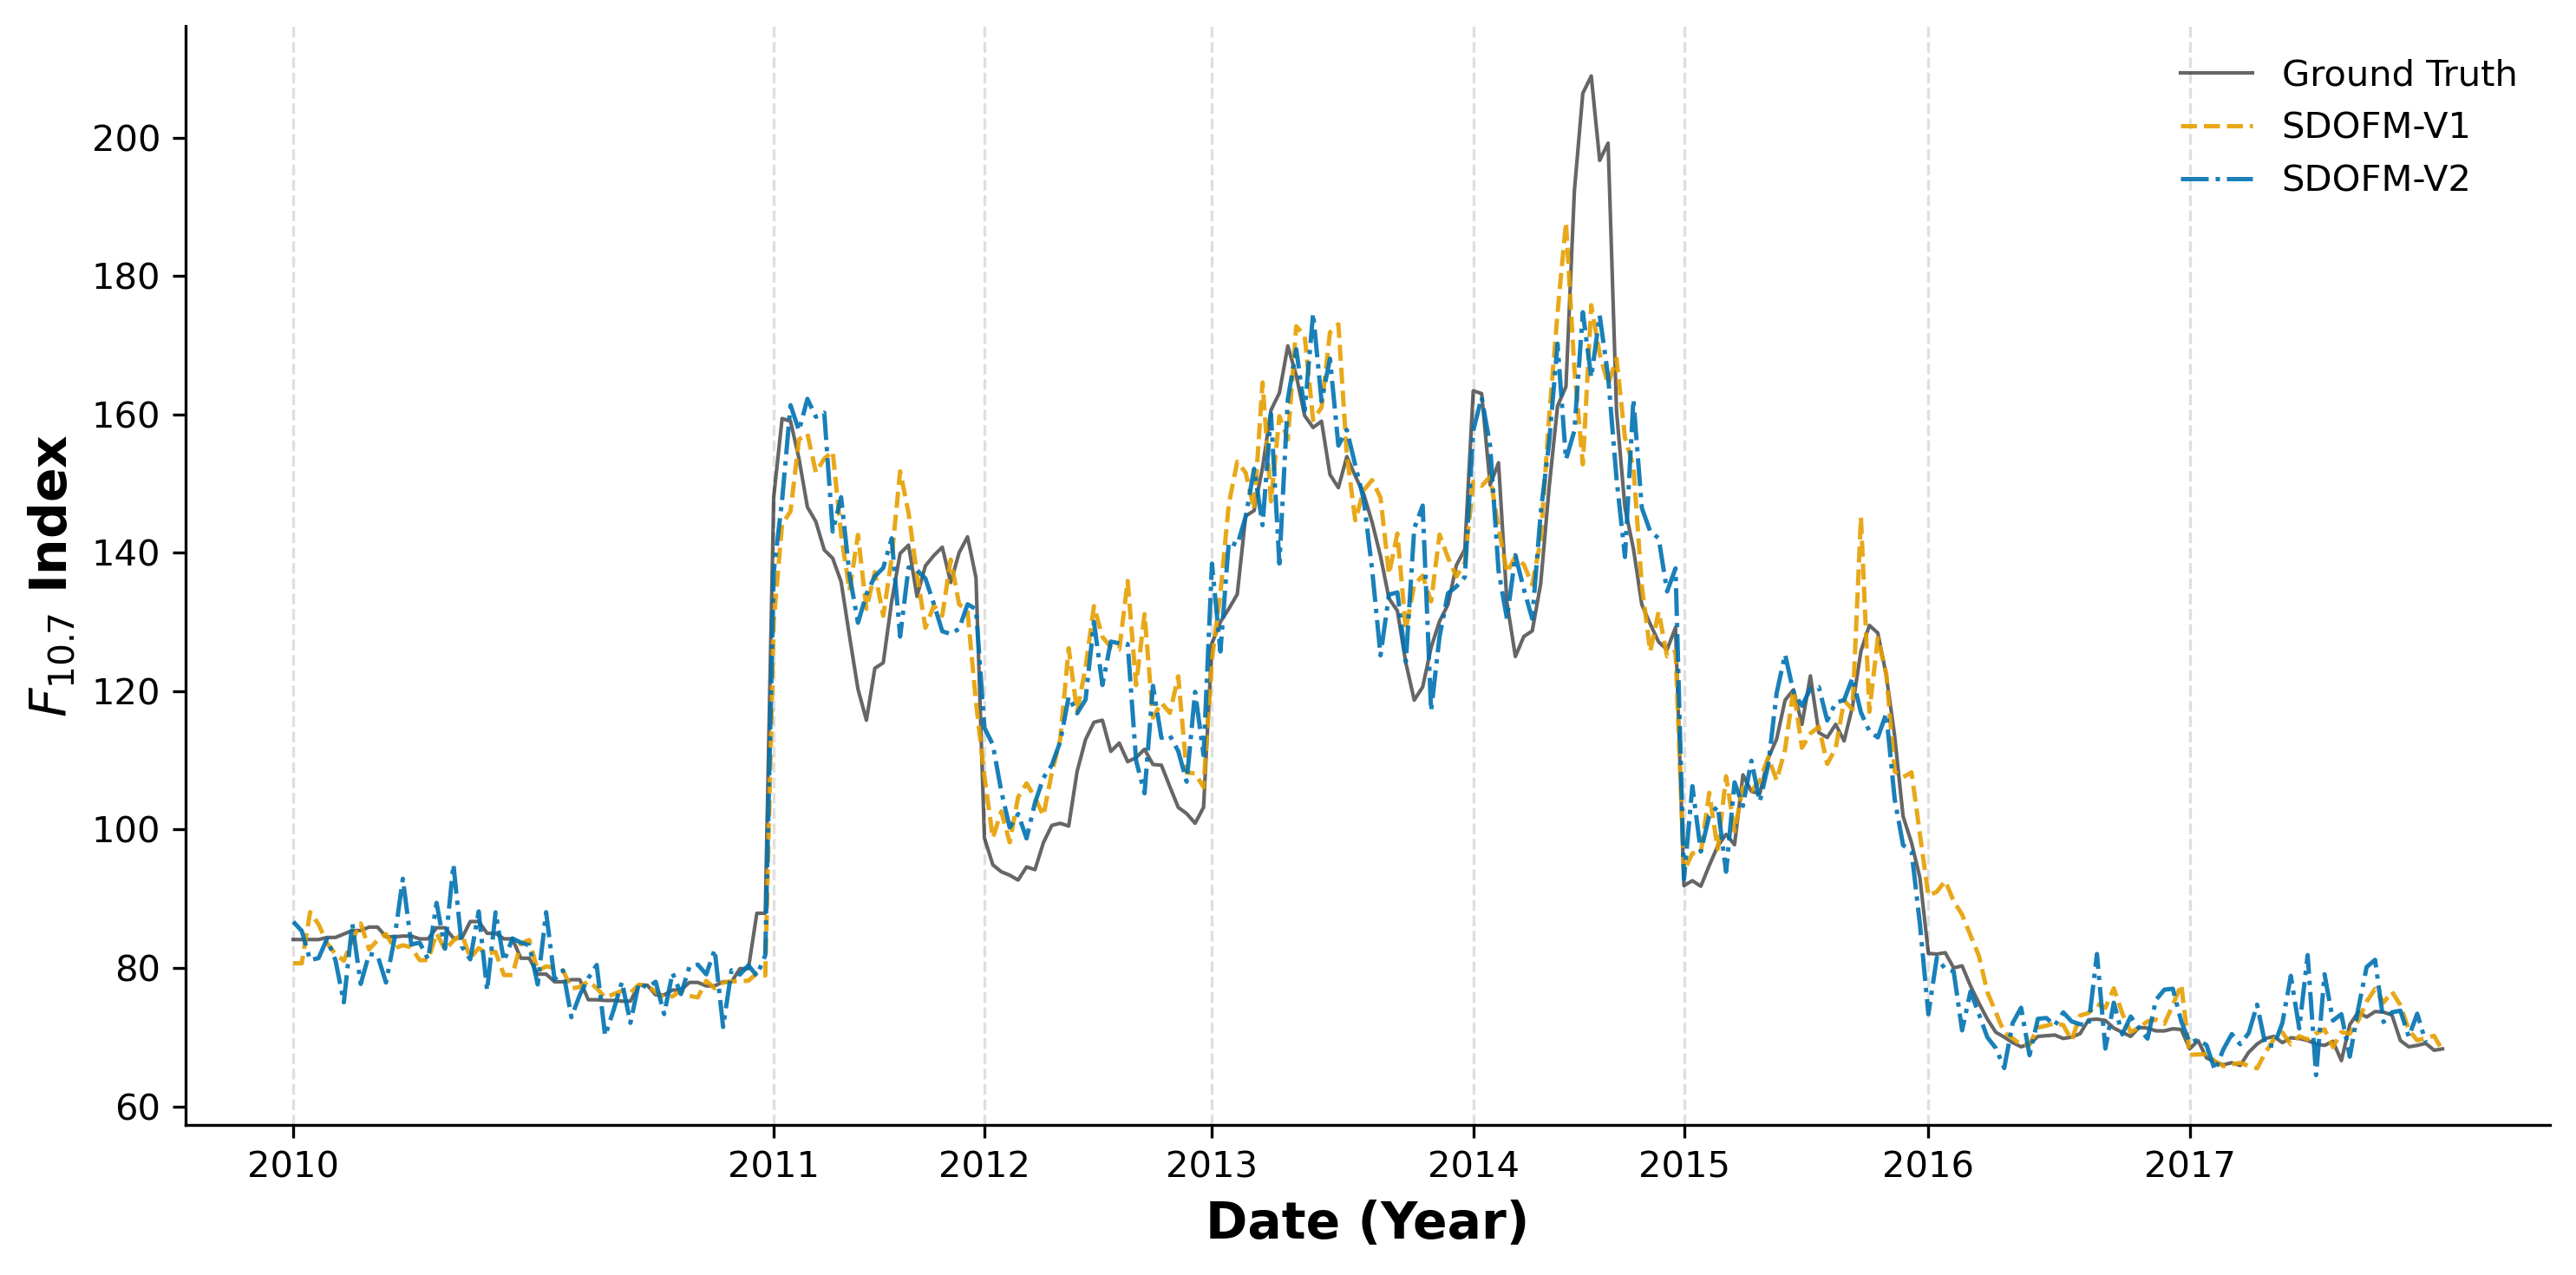

In [4]:
dates = pd.to_datetime(timestamps_v1)
years = dates.year
x_v1 = np.arange(len(dates))
x_v2 = np.arange(len(timestamps_v2))


fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Ground Truth: Dark grey or Black is better for the "anchor" data
ax.plot(x_v1, y_v1, label="Ground Truth", color='black', linewidth=1, alpha=0.6)

# Model 1: Orange (Okabe-Ito)
ax.plot(x_v1, preds_sdofmv1, label="SDOFM-V1", color='#E69F00', 
        linewidth=1.2, alpha=0.9, linestyle='--')

# Model 2 (AIA): Darker Blue (Okabe-Ito) - distinct from orange
ax.plot(x_v2, preds_sdofmv2_all, label="SDOFM-V2", color='#0072B2', 
        linewidth=1.2, alpha=0.9, linestyle='-.')

ax.set_xlabel("Date (Year)", fontsize=14, fontweight='bold')
ax.set_ylabel("$F_{10.7}$ Index", fontsize=14, fontweight='bold')

unique_years, indices = np.unique(years, return_index=True)

ax.set_xticks(indices)
ax.set_xticklabels(unique_years)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.4)

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("f107_result_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()